> ### Public copy (demo data)
>
> The client's 2024 survey cannot be shared publicly, so it is **not in this repository**. Instead,
> `scripts/make_demo_workbook.py` creates `data/raw/engagement_survey_2024.xlsx`, a stand-in file
> with the same structure as the real one: the same sheet name, 22 columns, 42 rows, category
> headers, two 1-10 items and the same delta-from-company-mean format. Only the numbers are
> **invented**.
>
> This means the code, the method and the reasoning below are the originals, but every number,
> table and chart comes from demo data. Phase 1 figures are labelled **DEMO** instead of REAL.
> Where a result depends on the client's numbers, the text says what to look for instead of
> quoting them. Everything the notebooks produce is written to `outputs/`.
>
> To run on the real data, put the client workbook in `data/raw/` and set `data.provenance` to
> `real` in `config/config.yaml`. The labels then switch back.
 

# 04 — Synthetic Data: Generation & Validation

|  |  |
|---|---|
| **Purpose** | Build the individual-level, multi-wave, demographically rich dataset Phase 2 needs, **calibrated to the aggregated survey workbook**. Then clear two blocking quality gates before any modelling. |
| **Input** | survey workbook (`data/raw/`) |
| **Outputs** | `data/synthetic/` panel + item map + generator params · `tab13`, `tab14` · `fig05` |
| **Objectives** | Foundation for RO2 and RO3(b): the refined objectives are defined in the README |

> **Claim boundary (applies to everything from here on).** Synthetic data demonstrates **method
> capability**, never facts about a real workforce. The correlational structure is partly
> *imposed* from the literature and is disclosed in full below, so nothing here can be mistaken
> for discovery.
>
> In this public copy the calibration target is the demo workbook, so the panel is synthetic data
> calibrated to invented aggregates, two layers away from anything real.

In [1]:
# Environment setup
import sys
sys.path.insert(0, "../src")

import warnings

# Some numpy/BLAS builds emit spurious "divide by zero / overflow / invalid
# value encountered in matmul" RuntimeWarnings during ordinary matrix
# multiplication inside scikit-learn: floating-point error flags are read
# after the BLAS call and may have been set by BLAS internals. They are
# suppressed here ONLY because the conditions they would warn about are
# checked directly in code: synthetic/models operate on bounded ordinal data,
# and personas.build_personas raises if its standardised matrix is non-finite.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, synthetic, viz
from engagement.config import load_config, get_seed

cfg = load_config()
SEED = get_seed(cfg)
pd.set_option("display.max_colwidth", 90)
print(f"Config loaded · seed = {SEED}")

Config loaded · seed = 5496


---
## A. Generating the panel

**Decision box**

| | |
|---|---|
| **What** | 1,000 synthetic employees x 3 waves whose wave-1 department means reproduce the survey workbook department means, and whose construct correlations with a UWES engagement outcome are imposed from meta-analytic evidence (`config.yaml`). |
| **Why calibrate, not invent** | Anchoring to the real heatmap keeps the demonstration about *this* company. An invented or public HR dataset would prove nothing about the value of better data here. Synthetic data is a standard response to data scarcity rather than an improvisation, and must be shown to match its source before use (Lautrup et al., 2025). |
| **Why a Gaussian copula** | It controls marginals and dependence separately: department means can match reality exactly while inter-construct correlations follow theory (Bakker and Demerouti, 2017; Saks, 2006; Edmondson, 1999). |
| **Instrument-complete** | The constructs Phase 1 lacked (UWES engagement, personal resources, technology, justice, psychological safety, ESG) are added so their payoff can be shown, the RO4 argument for 2026. |
| **Data-quality implication** | Targets are reconstructed absolute scores on **native** scales (NB01), so the two 1–10 items keep their real scale: the flaw is reproduced, then fixed at analysis time. |
| **Feeds** | NB05 · `tab13`, `tab14`, `fig05`|

In [2]:
# Calibration targets: reconstructed ABSOLUTE department x item scores (native scales)
tidy = io.tidy(io.load_heatmap(cfg), cfg)
targets = quality.to_matrix(quality.reconstruct_absolute(tidy), "abs_value").drop(index="Company")
item_meta = tidy[~tidy["is_category_header"]][["item", "category", "scale"]].drop_duplicates()
print(f"targets: {targets.shape[0]} departments x {targets.shape[1]} items")

data, item_map = synthetic.generate(cfg, targets, item_meta)
print(f"synthetic panel: {data.shape[0]:,} rows "
      f"({cfg['synthetic']['n_employees']} employees x {cfg['synthetic']['n_waves']} waves), "
      f"{item_map.shape[0]} items ({(item_map.index.str.startswith('q')).sum()} real + "
      f"{(~item_map.index.str.startswith('q')).sum()} new)")
data.head(3)

targets: 19 departments x 34 items


[calibration] department-level loop stopped at worst error 0.1095 (> tolerance 0.05); individual-level raking handles the residual cells.
synthetic panel: 3,000 rows (1000 employees x 3 waves), 49 items (34 real + 15 new)


,employee_id,department,region,tenure,role_level,work_mode,wave,q01,q02,q03,...,pers_3,tech_1,tech_2,tech_3,just_1,just_2,psys_1,psys_2,esg_1,esg_2
0,E0000,A,Europe,>5y,junior,hybrid,1,3.0,4.0,5.0,...,4.0,5.0,5.0,4.0,5.0,5.0,5.0,3.0,4.0,5.0
1,E0001,P,US,>5y,lead,remote,1,3.0,3.0,5.0,...,4.0,3.0,4.0,4.0,3.0,3.0,4.0,3.0,4.0,4.0
2,E0002,Other (24),Israel,<1y,mid,onsite,1,3.0,4.0,4.0,...,4.0,3.0,3.0,2.0,4.0,3.0,4.0,4.0,4.0,2.0


**Read:** 1,000 employees × 3 waves, 49 items. 34 items are rebuilt from the 2024 instrument, and 15 are questions the 2024 survey never asked. Those 15 are the entire point of the exercise.

Look at the [calibration] line printed above. In this run it says the department-level loop stopped at a worst error of 0.1095, against a tolerance of 0.05. That line is a log, not an error.

Here is why it happens. Answers have to be whole numbers, so the loop can only move a department's mean in steps. It gets most cells inside the tolerance and then stops, because the next step would overshoot. A second pass then adjusts individual answers one at a time to close the remaining gaps.

Gate 1 below is what decides whether that second pass worked. The log is the diagnosis; the gate is the verdict.

---
## B. Gate 1: fidelity

Does aggregating the synthetic individuals back up reproduce the real heatmap? **Blocking**: the
notebook halts on failure.

In [3]:
fid = synthetic.validate_fidelity(data, item_map, targets, cfg)
print(f"worst |simulated − real| = {fid['worst_error']:.4f}  (tolerance {fid['tolerance']})")
print(f"department composite ranking reproduced: Spearman ρ = {fid['ranking_spearman']:.3f}")
print(f"GATE {'PASSED' if fid['passed'] else 'FAILED'}")
assert fid["passed"], "Fidelity gate failed — do not model on this data."
fid["report"].head(8)

worst |simulated − real| = 0.0300  (tolerance 0.05)
department composite ranking reproduced: Spearman ρ = 1.000
GATE PASSED


,max_abs_error,mean_abs_error
I feel comfortable sharing my ideas at work with peers and management.,0.0300,0.0121
I would recommend AFT to my friends.,0.0298,0.0107
I feel the HR team at Access Fintech care about my wellbeing.,0.0296,0.0080
"On a scale of one to ten, how well are you able to balance your work and personal commitments?",0.0291,0.0097
My manager keeps me informed about what is happening within my team and the wider business.,0.0291,0.0107
My work is appreciated by my Head of Department.,0.0288,0.0106
I am optimistic about Access Fintech's long-term success.,0.0287,0.0075
The executive team works as a cohesive team.,0.0287,0.0097


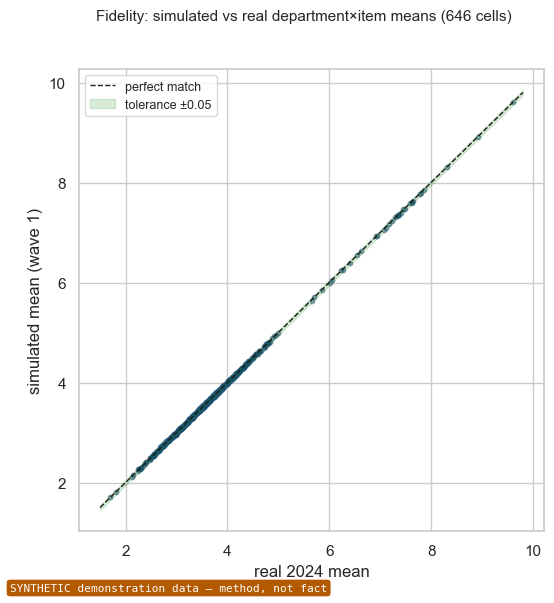

In [4]:
# Fidelity in one picture: every simulated department×item mean vs its real target.
qcols = [c for c in item_map.index if c.startswith("q")]
sim = data[data["wave"] == 1].groupby("department")[qcols].mean()
sim.columns = [item_map.loc[c, "item"] for c in qcols]
sim = sim[targets.columns].reindex(targets.index)   # align to targets

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(targets.to_numpy().ravel(), sim.to_numpy().ravel(),
           s=10, alpha=0.45, color="#1f4e79")
lo, hi = targets.min().min() - 0.2, targets.max().max() + 0.2
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect match")
ax.fill_between([lo, hi], [lo - 0.05, hi - 0.05], [lo + 0.05, hi + 0.05],
                alpha=0.15, color="green", label="tolerance ±0.05")
ax.set_xlabel("real 2024 mean"); ax.set_ylabel("simulated mean (wave 1)")
ax.legend(fontsize=9)
viz.save_figure(fig, "fig05_synthetic_fidelity", cfg, "synthetic",
                "Fidelity: simulated vs real department×item means (646 cells)")
plt.show()

**Read:** gate 1 compares the synthetic company against the workbook it was built from. Two things
must hold, and both are printed above.

1. **Every cell close enough.** For each department and each item, the synthetic average must sit
   within the tolerance of the original. Here the worst cell is 0.0300, against a tolerance of
   0.05.
2. **The department order unchanged.** Rank the 19 departments on both sides and compare the two
   rankings. Here Spearman ρ = 1.000: identical order.

The second condition is there because the first one is not enough on its own. Two departments can
differ by less than the tolerance, so a generator could pass on averages and still swap their
places. Order is what a client reads, who needs attention first, so a swapped order would make
the data useless.

Gate 1 blocks. If either condition fails, the run stops here and nothing downstream is produced.
`tests/test_synthetic.py` checks that it really does stop, rather than print a warning.

Passing means the synthetic company matches the real aggregates, while adding the
individual-level variation the aggregated workbook never had.

---
## C. Gate 2: plausibility and disclosure 

Does the data *behave* like engagement data? Three checks: responses inside their scale bounds;
achieved construct–engagement correlations against the **imposed** targets; and full disclosure
of that imposed structure. **Also blocking.**

In [5]:
pl = synthetic.validate_plausibility(data, item_map, cfg)
print("range violations:", pl["range_violations"] or "none")
print(f"engagement (UWES) block alpha = {pl['engagement_alpha']}  "
      f"(threshold >= {cfg['synthetic']['min_engagement_alpha']})")
print(f"worst |disattenuated − target| = {pl['worst_corr_gap']:.3f}  "
      f"(threshold <= {cfg['synthetic']['max_corr_gap']})")
print(f"items with extreme skew (|skew| > 2): {pl['n_extreme_skew']}")
print(f"GATE {'PASSED' if pl['passed'] else 'FAILED'}")
assert pl["passed"], "Plausibility gate failed — do not model on this data."
pl["achieved_vs_target"]

range violations: none
engagement (UWES) block alpha = 0.71  (threshold >= 0.6)
worst |disattenuated − target| = 0.047  (threshold <= 0.1)
items with extreme skew (|skew| > 2): 0
GATE PASSED


,target_latent_r,achieved_observed_r,alpha,disattenuated_r
construct,,,,
personal,0.48,0.310,0.70,0.442
development,0.45,0.326,0.82,0.429
social,0.36,0.325,0.90,0.407
demands,-0.30,-0.189,0.73,-0.262
satisfaction,0.60,0.454,0.84,0.589
justice,0.30,0.212,0.86,0.272
technology,0.35,0.216,0.68,0.311
psych_safety,0.35,0.228,0.63,0.344
esg,0.25,0.175,0.61,0.266


**Read:** the correlations come out smaller than the targets fed to the generator. Personal
resources was set at 0.48 and measures 0.310. That looks like a broken generator. It is not.

The target is a correlation between two *concepts*. The measured value is a correlation between
two *scales*, and each scale is only 2–3 questions long. Short scales carry measurement error, and
that error shrinks any correlation computed from them. The amount of shrinkage is known, not
guessed:

> measured r ≈ true r × √(α of scale A × α of scale B)

α is how reliable a scale is, between 0 and 1. Fewer questions means lower α, which means more
shrinkage.

So the check runs the formula backwards. Divide the measured value by √(α × α) and the original
should come back. It does: personal resources returns 0.442 against its 0.48 target, and the worst
gap in the whole table is 0.047, inside the 0.1 threshold. The structure put into the generator is
still there, it was simply measured with an imperfect instrument.

Two things carry forward.

1. Real 2026 data will shrink the same way. This is not an artefact of synthetic data.
2. The two-item scales are the least reliable here, psychological safety at α = 0.63 and ESG at
   α = 0.61, so they shrink the most. That is the case for at least 4 questions per construct in
   the 2026 instrument (NB05 section A, NB06 section C).

In [6]:
# Panel overview: demographics and waves (what the 2024 data does NOT have)
w1 = data[data["wave"] == 1]
overview = pd.DataFrame({
    "employees": [len(w1)], "departments": [w1["department"].nunique()],
    "waves": [data["wave"].nunique()],
    "remote_%": [round((w1["work_mode"] == "remote").mean() * 100, 1)],
    "regions": [w1["region"].nunique()],
})
overview

,employees,departments,waves,remote_%,regions
0,1000,19,3,24.8,5


In [7]:
path = synthetic.save(data, item_map, cfg)
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"]); t.mkdir(parents=True, exist_ok=True)
fid["report"].to_csv(t / "tab13_synthetic_fidelity.csv")
pl["achieved_vs_target"].to_csv(t / "tab14_synthetic_plausibility.csv")
print("saved:", path)
print("generator parameters saved alongside the data (provenance).")

saved: /Users/LapTop/github/engagement-analytics-pipeline/data/synthetic/synthetic_panel.csv
generator parameters saved alongside the data (provenance).


---
## Known limitations of the generator: measured, not asserted

| # | Limitation | Handling |
|---|---|---|
| 1 | When a department's target sits near the top of the scale, the generator has little room left to vary answers, so the spread inside that cell shrinks. | Unavoidable when matching ordinal data to targets at the boundary. Check the tightest cells before reading NB05: in this run the smallest within-cell sd is 0.27 against a typical 0.85, so no cell is degenerate. |
| 2 | `balance` is the reverse of `demands` (latent r ≈ −0.97). | Only `balance` enters the models, enforced in `DRIVER_CONSTRUCTS`. |
| 3 | Items per construct vary from 2 to 13, so reliability varies with them (α 0.61 to 0.91 in this run). | Read the disattenuated column in gate 2. This is also the case for at least 4 items per construct in 2026. |
| 4 | `social` merges manager, team and culture into one block: high α, but coarse. | If `social` ranks top, the target is ambiguous. The 2026 instrument separates them. |
| 5 | Demographics are drawn independently of each other and of department. | Persona mixes come out cleaner than reality would be. |
| 6 | Two departments whose composite scores are effectively tied cannot be ordered reliably: their rank can swap between seeds. | The aggregated workbook cannot tell them apart in the first place, so the ambiguity comes from the source, not the generator. Gate 1 reports the rank correlation for every run. |

These are properties of the demonstration *data*, not of the method. Rows 3 and 4 are two of the
reasons the 2026 instrument needs longer scales and separated constructs.

---
## Handover

Both gates passed. The panel reproduces the 2024 aggregate profile within tolerance, carries
disclosed theory-consistent structure, and contains what the real data lacks: an engagement
outcome, demographics, department sizes and three waves. Modelling may proceed.

**Next:** `05_phase2_modelling.ipynb`.

---
## References

Bakker, A.B. and Demerouti, E. (2017) 'Job demands–resources theory: taking stock and looking
forward', *Journal of Occupational Health Psychology*, 22(3), pp. 273–285.

Edmondson, A. (1999) 'Psychological safety and learning behavior in work teams',
*Administrative Science Quarterly*, 44(2), pp. 350–383.

Lautrup, A.D., Hyrup, T., Zimek, A. and Schneider-Kamp, P. (2025) 'Systematic review of
generative modelling tools and utility metrics for fully synthetic tabular data',
*ACM Computing Surveys*, 57(4), pp. 1–38.

Saks, A.M. (2006) 'Antecedents and consequences of employee engagement', *Journal of
Managerial Psychology*, 21(7), pp. 600–619.

Schaufeli, W.B. and Bakker, A.B. (2004) *UWES – Utrecht Work Engagement Scale: preliminary
manual*. Utrecht: Occupational Health Psychology Unit, Utrecht University.